# DCASE 2025 Task 2, Model vergelijking

We vergelijken in deze notebook twee pre-trained audio feature extractors (BEATs en EAT) met de officiële DCASE baseline voor anomaly detection op machinegeluiden.

### De pipeline in het kort

De feature-extraction (BEATs en EAT) en de vergelijking met de baseline zijn gedraaid op de development set van DCASE 2025 Task 2. Per machine is er een train-set met alleen normale geluiden, en een test-set met normale en abnormale geluiden, waar we op meten of we defecten goed zien. Die bestanden staan lokaal in Victor/data/dcase2025t2/dev_data/raw/. Daar zitten de zeven machinemappen met de ruwe .wav-bestanden van 10 seconden en 16 kHz.

BEATs en EAT zijn niet op deze DCASE-data getraind. Ze zijn eerder voorgetraind op AudioSet, een grote algemene audiocollectie. Wij gebruiken ze alleen als feature extactor. De aanpak daarvoor komt uit UASD_BEATs.ipynb en UASD_EAT.ipynb en is in run_all_models.py geautomatiseerd. UASD_EXTRA.ipynb (fine-tuning) hin deze notebook nog niet meegenomen.

run_all_models.py leest de audio uit Victor/data/dcase2025t2/dev_data/raw/, haalt met BEATs en EAT features op en slaat die op in Victor/features/BEATs/dcase2025t2_features/ en Victor/features/EAT/dcase2025t2_features/, zodat we niet elke keer opnieuw hoeven te rekenen. Daarna doet het script PCA en KNN voor anomalie detectie, en schrijft de scores weg in Victor/results_all_models.json. Dit vergelijkingsnotebook Week_6_experiment_comparison.ipynb leest die results_all_models.json en de baseline-cijfers van DCASE en vergelijken we de resultaten.

### Modellen
We vergelijken vier modellen. De DCASE baseline MSE is een autoencoder op log-mel spectrogram, hoge reconstructiefout geldt als anomalie. De DCASE baseline MAHALA gebruikt de Mahalanobis-afstand op dezelfde autoencoder-features. BEATs (frozen) is een voorgetrainde audio-transformer op ruwe audio met mean-pooling, EAT (frozen) is eveneens een voorgetrainde transformer maar op mel-spectrogram en gebruikt het CLS-token als embedding.


### Belangrijkste metrics uitgelegd


 AUC source meet hoe goed anomalieën in het brondomein worden gedetecteerd, AUC target hoe goed dat in een onbekend domein lukt. pAUC kijkt alleen naar het gebied met weinig false positives (FPR < 10%). Precision is het aandeel echte anomalieën onder wat het model als anomaly bestempelt, recall het aandeel gevonden anomalieën van het totaal aantal echte anomalieën. F1 is de balans tussen precision en recall. Ω (uit de DCASE) is het harmonisch gemiddelde van alle AUC- en pAUC-scores en is de officiële DCASE-rankingmetric.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

# standaard figuurgrootte en lettergrootte voor alle plots
matplotlib.rcParams['figure.figsize'] = (16, 8)
matplotlib.rcParams['font.size'] = 12
# getallen in tabellen altijd met twee decimalen tonen
pd.set_option('display.float_format', '{:.2f}'.format)

# lijst van alle machinetypes in de dataset
MACHINES = ["bearing", "fan", "gearbox", "slider", "ToyCar", "ToyTrain", "valve"]

# resultaten van run_all_models.py inladen (json-bestand)
with open(Path("results_all_models.json")) as f:
    raw_results = json.load(f)

print(f"Loaded results for {len(raw_results)} models: {list(raw_results.keys())}")

Loaded results for 2 models: ['BEATs (frozen)', 'EAT (frozen)']


## 1. Baseline resultaten (officiële DCASE 2025 Task 2 pagina)

Dit zijn de scores van het officiële baseline systeem dat elk team moet proberen te verslaan. De baseline gebruikt een autoencoder die getraind wordt op normaal geluid. Als het model een geluid niet goed kan reconstrueren, is dat waarschijnlijk een anomalie.

Er zijn twee varianten, MSE gebruikt de gemiddelde kwadratische fout als anomaly score. MAHALA gebruikt de Mahalanobis-afstand (houdt rekening met correlaties tussen features).

In [11]:
# baseline-scores van de officiële DCASE 2025 pagina (handmatig overgenomen)
baseline = {
    "Machine":           ["bearing", "fan", "gearbox", "slider", "ToyCar", "ToyTrain", "valve"],
    "MSE_AUC_src":       [66.53, 70.96, 64.80, 70.10, 71.05, 61.76, 63.53],
    "MSE_AUC_tgt":       [53.15, 38.75, 50.49, 48.77, 53.52, 56.46, 67.18],
    "MSE_pAUC":          [61.12, 49.46, 52.49, 52.32, 49.70, 50.19, 57.35],
    "MAHALA_AUC_src":    [63.63, 77.99, 73.26, 73.79, 73.17, 50.87, 56.22],
    "MAHALA_AUC_tgt":    [59.03, 38.56, 51.61, 50.27, 50.91, 46.15, 61.00],
    "MAHALA_pAUC":       [61.86, 50.82, 55.07, 53.61, 49.05, 48.32, 52.53],
}

# van dictionary een pandas-dataframe maken
df_base = pd.DataFrame(baseline)
# extra rij toevoegen met het gemiddelde over alle machines
avg = {"Machine": "GEMIDDELD"}
for c in df_base.columns[1:]:
    avg[c] = df_base[c].mean()
df_base = pd.concat([df_base, pd.DataFrame([avg])], ignore_index=True)

print("DCASE 2025 Task 2 - Baseline Scores (Development Dataset)")

# tabel tonen: percentages met twee decimalen, hoogste waarde per kolom groen
display(df_base.style
    .format({c: "{:.2f}%" for c in df_base.columns[1:]})
    .set_caption("Baseline AUC/pAUC Scores (%)")
    .highlight_max(axis=0, subset=df_base.columns[1:], props='font-weight: bold')
)

DCASE 2025 Task 2 - Baseline Scores (Development Dataset)


,Machine,MSE_AUC_src,MSE_AUC_tgt,MSE_pAUC,MAHALA_AUC_src,MAHALA_AUC_tgt,MAHALA_pAUC
0,bearing,66.53%,53.15%,61.12%,63.63%,59.03%,61.86%
1,fan,70.96%,38.75%,49.46%,77.99%,38.56%,50.82%
2,gearbox,64.80%,50.49%,52.49%,73.26%,51.61%,55.07%
3,slider,70.10%,48.77%,52.32%,73.79%,50.27%,53.61%
4,ToyCar,71.05%,53.52%,49.70%,73.17%,50.91%,49.05%
5,ToyTrain,61.76%,56.46%,50.19%,50.87%,46.15%,48.32%
6,valve,63.53%,67.18%,57.35%,56.22%,61.00%,52.53%
7,GEMIDDELD,66.96%,52.62%,53.23%,66.99%,51.08%,53.04%


## 2. Onze resultaten, BEATs en EAT

### (Uitleg onze begeleider)

### BEATs (frozen)

We gebruiken BEATs (Bidirectional Encoder Representations from Audio Transformers), een model dat vooraf is getraind op AudioSet. BEATs neemt ruwe audio op (16 kHz) en maakt daar intern een spectrogram van. We halen één feature-vector per bestand door over alle tijdstappen te middelen (mean pooling), dat levert 768 getallen per opname. Voor anomaly detection doen we eerst PCA naar 128 dimensies en daarna KNN met k=5 en een drempel op het 95e percentiel.

### EAT (frozen)

EAT is ook vooraf getraind op AudioSet. We voeren het model een mel-spectrogram in met 128 mel bins en 512 frames, genormaliseerd. In plaats van te middelen nemen we de CLS-token (de eerste positie van de modeloutput) als samenvatting van het audiofragment, dat is weer een vector van 768 dimensies (Chen et al., 2024). Ook hier gebruiken we PCA naar 128 dimensies en daarna KNN (k=5, drempel 95e percentiel) voor anomaly detection.

In [16]:
# zet de resultaten van één model om naar een dataframe met kolommen per metric
def results_to_df(model_results, model_name):
    rows = []
    for entry in model_results:
        rows.append({
            "Machine": entry["machine"],
            f"{model_name}_AUC_src": entry["AUC_source"],
            f"{model_name}_AUC_tgt": entry["AUC_target"],
            f"{model_name}_pAUC": entry["pAUC"],
            f"{model_name}_Prec": entry["Precision"],
            f"{model_name}_Recall": entry["Recall"],
            f"{model_name}_F1": entry["F1"],
        })
    return pd.DataFrame(rows)

# resultaten van BEATs en EAT elk in een dataframe
df_beats = results_to_df(raw_results["BEATs (frozen)"], "BEATs")
df_eat = results_to_df(raw_results["EAT (frozen)"], "EAT")

# beide dataframes samenvoegen op kolom Machine
df_ours = df_beats.merge(df_eat, on="Machine")

# gemiddelde over alle machines als extra rij toevoegen
avg_row = {"Machine": "GEMIDDELD"}
for c in df_ours.columns[1:]:
    vals = df_ours[c].dropna()
    avg_row[c] = vals.mean() if len(vals) > 0 else None
df_ours = pd.concat([df_ours, pd.DataFrame([avg_row])], ignore_index=True)

print("Onze modellen, resultaten (development dataset)")

# tabel tonen, ontbrekende waarden als --
display(df_ours.style
    .format({c: "{:.2f}" for c in df_ours.columns[1:]}, na_rep="--")
    .set_caption("BEATs en EAT scores (%)")
)

Onze modellen, resultaten (development dataset)


,Machine,BEATs_AUC_src,BEATs_AUC_tgt,BEATs_pAUC,BEATs_Prec,BEATs_Recall,BEATs_F1,EAT_AUC_src,EAT_AUC_tgt,EAT_pAUC,EAT_Prec,EAT_Recall,EAT_F1
0,bearing,56.16,48.00,50.05,50.00,7.00,12.28,66.04,57.12,57.63,78.57,22.00,34.38
1,fan,49.52,44.36,50.68,49.53,53.00,51.21,58.28,40.36,49.00,50.98,52.00,51.49
2,gearbox,62.12,57.08,53.21,66.67,4.00,7.55,62.80,58.56,51.79,61.54,16.00,25.40
3,slider,50.00,50.00,50.00,0.00,0.00,0.00,76.92,56.28,50.68,52.94,9.00,15.38
4,ToyCar,46.00,59.00,51.89,48.08,50.00,49.02,61.00,43.60,47.74,53.29,89.00,66.67
5,ToyTrain,50.00,50.00,50.00,0.00,0.00,0.00,65.04,61.64,54.58,61.22,60.00,60.61
6,valve,50.00,50.00,50.00,0.00,0.00,0.00,88.44,69.96,70.05,90.48,19.00,31.40
7,GEMIDDELD,51.97,51.21,50.83,30.61,16.29,17.15,68.36,55.36,54.50,64.15,38.14,40.76


## 3. Head-to-head vergelijking van Baseline vs. BEATs vs. EAT

 We vergelijken per metric (AUC source, AUC target, pAUC) alle modellen naast elkaar. De hoogste score per rij wordt groen gemarkeerd.

In [4]:
# bouwt voor één metric een vergelijkingstabel: baseline mse, baseline mahala, beats, eat
def build_comparison(metric_suffix):
    baseline_mse_col = f"MSE_{metric_suffix}"
    baseline_mahala_col = f"MAHALA_{metric_suffix}"
    
    rows = []
    for i, m in enumerate(MACHINES):
        row = {"Machine": m}
        row["Baseline MSE"] = baseline[baseline_mse_col][i]
        row["Baseline MAHALA"] = baseline[baseline_mahala_col][i]
        
        # zoek de resultaten voor deze machine in de json
        beats_entry = next((e for e in raw_results["BEATs (frozen)"] if e["machine"] == m), None)
        eat_entry = next((e for e in raw_results["EAT (frozen)"] if e["machine"] == m), None)
        
        # vul de juiste metric in afhankelijk van metric_suffix
        if metric_suffix == "AUC_src":
            row["BEATs (frozen)"] = beats_entry["AUC_source"] if beats_entry else None
            row["EAT (frozen)"] = eat_entry["AUC_source"] if eat_entry else None
        elif metric_suffix == "AUC_tgt":
            row["BEATs (frozen)"] = beats_entry["AUC_target"] if beats_entry else None
            row["EAT (frozen)"] = eat_entry["AUC_target"] if eat_entry else None
        elif metric_suffix == "pAUC":
            row["BEATs (frozen)"] = beats_entry["pAUC"] if beats_entry else None
            row["EAT (frozen)"] = eat_entry["pAUC"] if eat_entry else None
        rows.append(row)
    
    df = pd.DataFrame(rows)
    # gemiddelde-rij toevoegen
    avg = {"Machine": "GEMIDDELD"}
    for c in df.columns[1:]:
        vals = df[c].dropna()
        avg[c] = vals.mean() if len(vals) > 0 else None
    df = pd.concat([df, pd.DataFrame([avg])], ignore_index=True)
    return df

# welke metric bij welke beschrijving hoort
metric_labels = {
    "AUC_src": "AUC source domain (hoe goed detecteert het model anomalieën in bekende condities?)",
    "AUC_tgt": "AUC target domain (hoe goed generaliseert het model naar onbekende condities?)",
    "pAUC": "Partial AUC (hoe goed bij lage false-positive rates? Strengere metric)",
}

# voor elke metric: tabel bouwen en tonen, hoogste score per rij groen
for metric, label in metric_labels.items():
    df = build_comparison(metric)
    
    print(f"  {label}")
    model_cols = [c for c in df.columns if c != "Machine"]
    display(df.style
        .format({c: "{:.2f}%" for c in model_cols}, na_rep="--")
        .highlight_max(axis=1, subset=model_cols, props='font-weight: bold')
        .set_caption(f"{metric} vergelijking (%)")
    )

  AUC source domain (hoe goed detecteert het model anomalieën in bekende condities?)


,Machine,Baseline MSE,Baseline MAHALA,BEATs (frozen),EAT (frozen)
0,bearing,66.53%,63.63%,56.16%,66.04%
1,fan,70.96%,77.99%,49.52%,58.28%
2,gearbox,64.80%,73.26%,62.12%,62.80%
3,slider,70.10%,73.79%,50.00%,76.92%
4,ToyCar,71.05%,73.17%,46.00%,61.00%
5,ToyTrain,61.76%,50.87%,50.00%,65.04%
6,valve,63.53%,56.22%,50.00%,88.44%
7,GEMIDDELD,66.96%,66.99%,51.97%,68.36%


  AUC target domain (hoe goed generaliseert het model naar onbekende condities?)


,Machine,Baseline MSE,Baseline MAHALA,BEATs (frozen),EAT (frozen)
0,bearing,53.15%,59.03%,48.00%,57.12%
1,fan,38.75%,38.56%,44.36%,40.36%
2,gearbox,50.49%,51.61%,57.08%,58.56%
3,slider,48.77%,50.27%,50.00%,56.28%
4,ToyCar,53.52%,50.91%,59.00%,43.60%
5,ToyTrain,56.46%,46.15%,50.00%,61.64%
6,valve,67.18%,61.00%,50.00%,69.96%
7,GEMIDDELD,52.62%,51.08%,51.21%,55.36%


  Partial AUC (hoe goed bij lage false-positive rates? Strengere metric)


,Machine,Baseline MSE,Baseline MAHALA,BEATs (frozen),EAT (frozen)
0,bearing,61.12%,61.86%,50.05%,57.63%
1,fan,49.46%,50.82%,50.68%,49.00%
2,gearbox,52.49%,55.07%,53.21%,51.79%
3,slider,52.32%,53.61%,50.00%,50.68%
4,ToyCar,49.70%,49.05%,51.89%,47.74%
5,ToyTrain,50.19%,48.32%,50.00%,54.58%
6,valve,57.35%,52.53%,50.00%,70.05%
7,GEMIDDELD,53.23%,53.04%,50.83%,54.50%


## 4. Official score (Ω), de DCASE ranking metric

De officiële DCASE score Ω is het harmonisch gemiddelde van alle AUC en pAUC scores.  Dit dwingt het om consistent goed te zijn op alle machines. 

In [5]:
# harmonisch gemiddelde uit scipy (voor officiële DCASE-score)
from scipy.stats import hmean

# berekent de officiële score omega: harmonisch gemiddelde van alle auc- en pauc-waarden
def compute_omega(auc_src, auc_tgt, pauc_list):
    all_vals = []
    for vals in [auc_src, auc_tgt, pauc_list]:
        # alle waarden in fractie (0-1) toevoegen, nullen en negatieven overslaan
        all_vals.extend([v / 100.0 for v in vals if v is not None and v > 0])
    if len(all_vals) == 0:
        return None
    # harmonisch gemiddelde keer 100 voor percentage
    return hmean(all_vals) * 100

scores = {}

# omega voor beide baselines
scores["Baseline MSE"] = compute_omega(
    baseline["MSE_AUC_src"], baseline["MSE_AUC_tgt"], baseline["MSE_pAUC"]
)
scores["Baseline MAHALA"] = compute_omega(
    baseline["MAHALA_AUC_src"], baseline["MAHALA_AUC_tgt"], baseline["MAHALA_pAUC"]
)

# omega voor elk model uit onze resultaten
for model_name, results in raw_results.items():
    auc_s = [r["AUC_source"] for r in results]
    auc_t = [r["AUC_target"] for r in results]
    pauc = [r["pAUC"] for r in results]
    scores[model_name] = compute_omega(auc_s, auc_t, pauc)

# referentiescores van de beste DCASE 2025 teams (voor vergelijking)
ref_scores = {
    "DCASE #1 Wang_MYPS": 61.63,
    "DCASE #5 Jiang_THUEE": 59.79,
    "DCASE #10 Huang_XJU": 58.14,
}

print("  Officiële score (Ω), harmonisch gemiddelde van alle AUC/pAUC")
print("\n  DCASE 2025 Top Teams (referentie)")
for name, score in ref_scores.items():
    print(f"  {name:<35} {score:.2f}%")
print()
print("Baselines")
for name in ["Baseline MSE", "Baseline MAHALA"]:
    print(f"  {name:<35} {scores[name]:.2f}%")
print()
print("Onze modellen")
for name in ["BEATs (frozen)", "EAT (frozen)"]:
    s = scores[name]
    # verschil ten opzichte van MSE-baseline
    delta = s - scores["Baseline MSE"] if s else 0
    marker = "(hoger)" if delta > 0 else "(lager)"
    print(f"  {name:<35} {s:.2f}%  ({marker} {abs(delta):.2f}% vs MSE baseline)")


  Officiële score (Ω), harmonisch gemiddelde van alle AUC/pAUC

  DCASE 2025 Top Teams (referentie)
  DCASE #1 Wang_MYPS                  61.63%
  DCASE #5 Jiang_THUEE                59.79%
  DCASE #10 Huang_XJU                 58.14%

Baselines
  Baseline MSE                        56.26%
  Baseline MAHALA                     55.34%

Onze modellen
  BEATs (frozen)                      51.04%  ((lager) 5.22% vs MSE baseline)
  EAT (frozen)                        57.50%  ((hoger) 1.24% vs MSE baseline)


## 5. Visualisaties

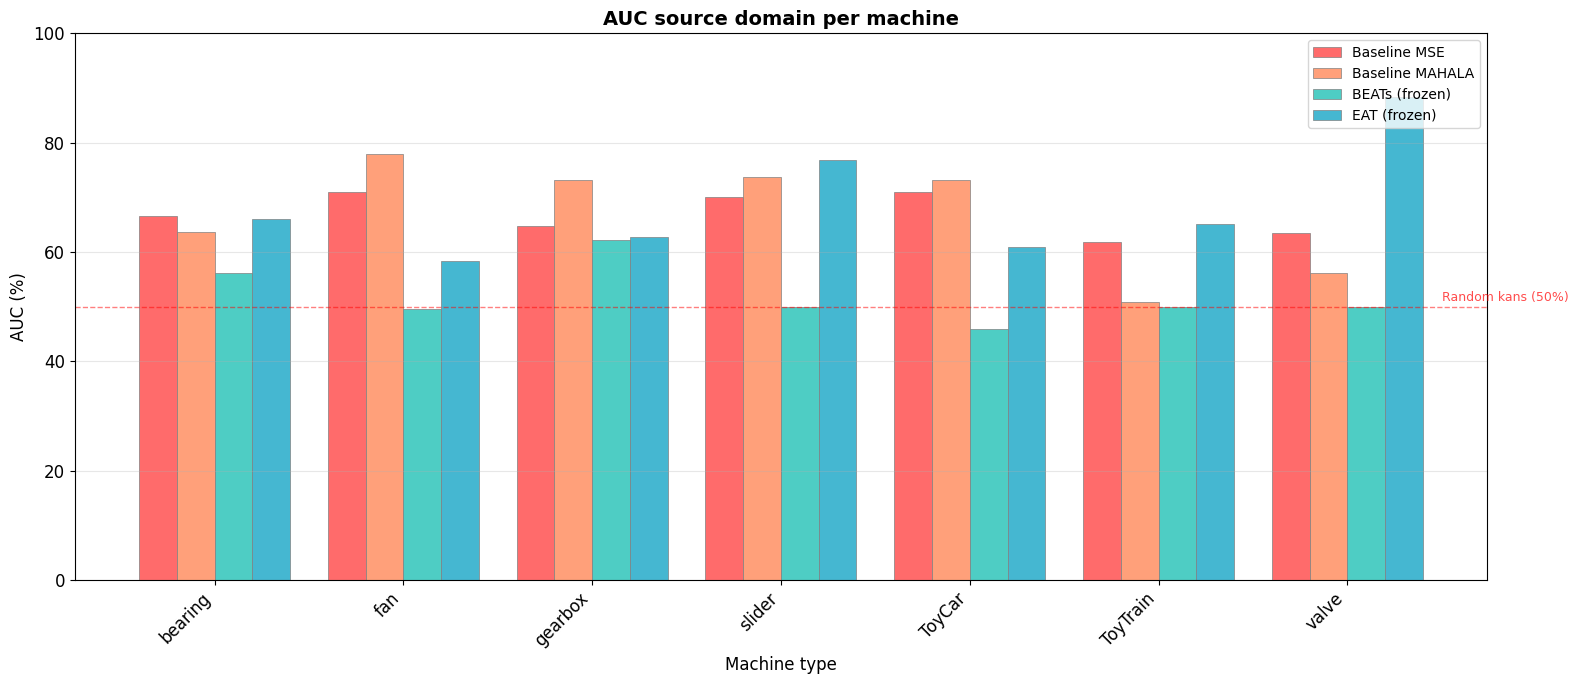

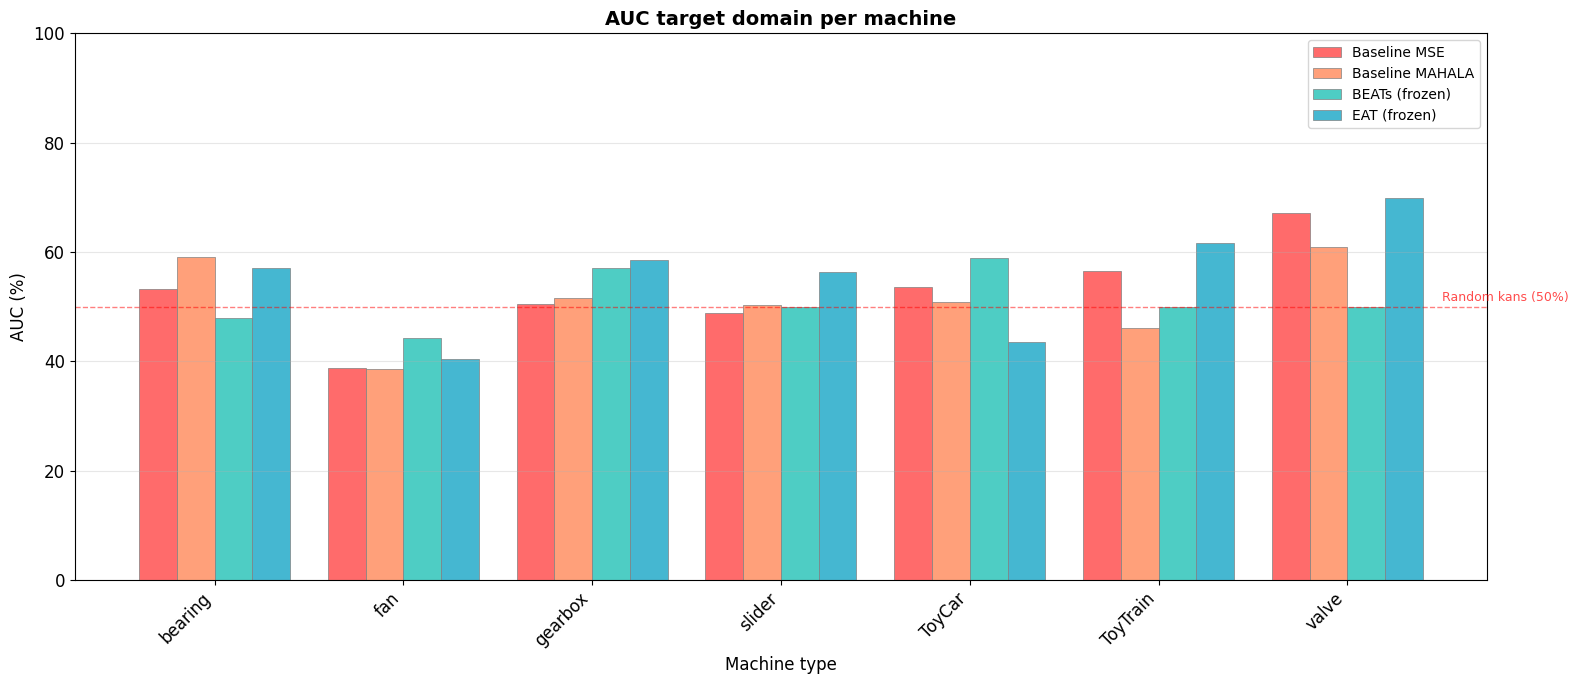

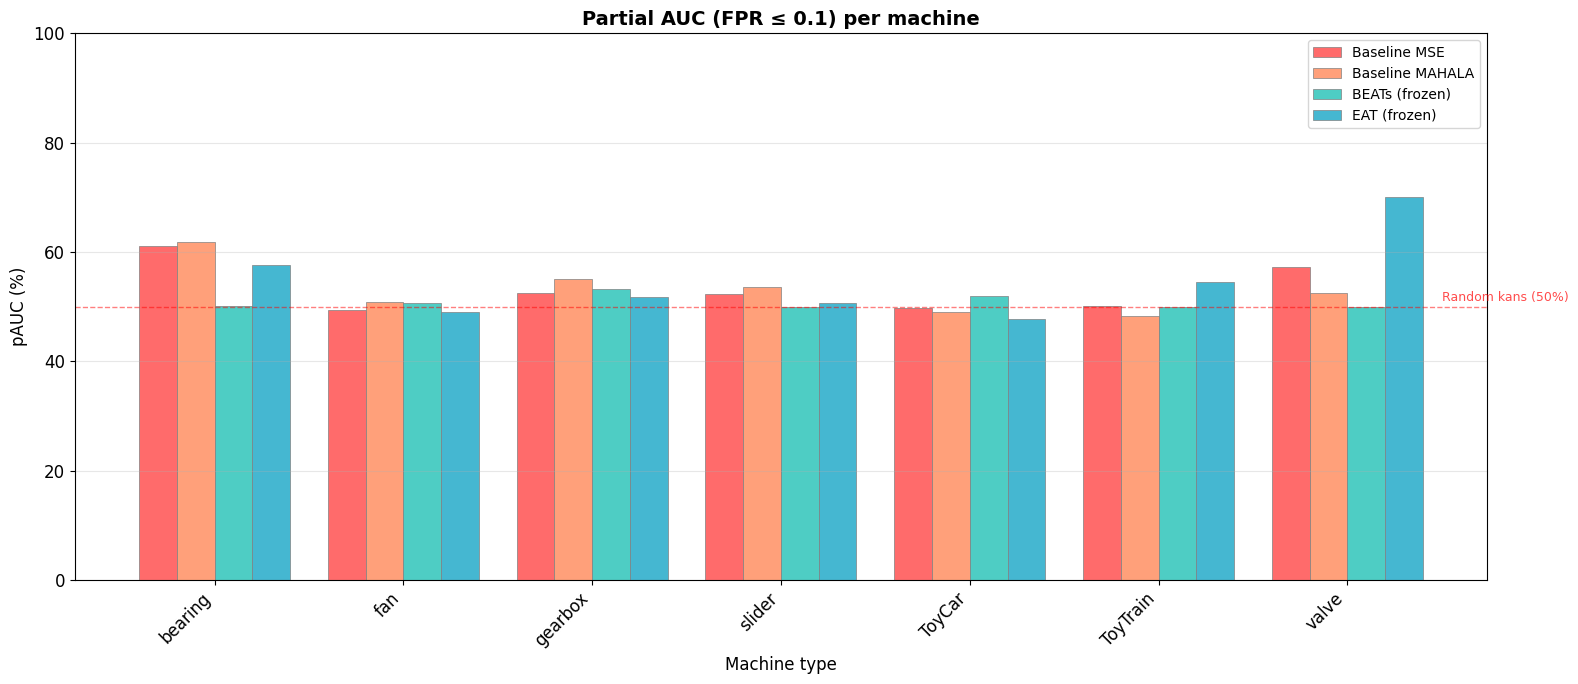

In [14]:
# maakt een staafdiagram voor één metric: alle modellen naast elkaar per machine
def plot_comparison_bars(metric_suffix, ylabel, title):
    df = build_comparison(metric_suffix)
    # gemiddelde-rij weglaten voor de plot
    df_plot = df[df["Machine"] != "GEMIDDELD"].copy()
    model_cols = [c for c in df_plot.columns if c != "Machine"]
    
    # x-posities voor elke machine, breedte van de staven
    x = np.arange(len(df_plot))
    width = 0.8 / len(model_cols)
    colors = ['#FF6B6B', '#FFA07A', '#4ECDC4', '#45B7D1']
    
    fig, ax = plt.subplots(figsize=(16, 7))
    for i, (model, color) in enumerate(zip(model_cols, colors)):
        # ontbrekende waarden als nul tekenen voor de plot
        vals = df_plot[model].fillna(0).values
        # elke modelgroep een beetje verschuiven zodat staven naast elkaar staan
        offset = (i - len(model_cols)/2 + 0.5) * width
        ax.bar(x + offset, vals, width, label=model, color=color, edgecolor='gray', linewidth=0.5)
    
    # lijn bij 50% (random gokken)
    ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(len(x)-0.5, 51, 'Random kans (50%)', color='red', alpha=0.7, fontsize=9)
    ax.set_xlabel('Machine type', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df_plot['Machine'], rotation=45, ha='right')
    ax.legend(loc='upper right', fontsize=10)
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_comparison_bars('AUC_src', 'AUC (%)', 'AUC source domain per machine')
plot_comparison_bars('AUC_tgt', 'AUC (%)', 'AUC target domain per machine')
plot_comparison_bars('pAUC', 'pAUC (%)', 'Partial AUC (FPR ≤ 0.1) per machine')

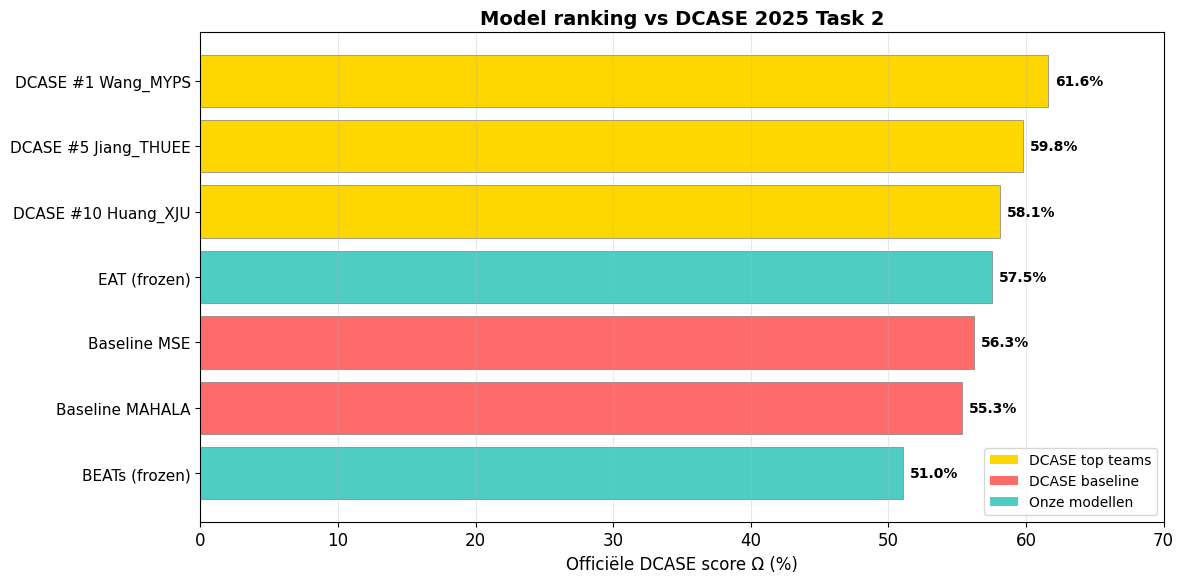

In [18]:
# Official Score ranking visualisatie
# referentie-teams, baselines en onze modellen in één dict voor de staafdiagram
all_scores = {}
all_scores.update(ref_scores)
all_scores.update(scores)

# alle omega-scores sorteren van hoog naar laag voor de staafdiagram
sorted_scores = sorted(all_scores.items(), key=lambda x: x[1] if x[1] else 0, reverse=True)
names = [s[0] for s in sorted_scores if s[1] is not None]
values = [s[1] for s in sorted_scores if s[1] is not None]

# kleur per type: goud voor DCASE-teams, rood voor baselines, groen voor onze modellen
colors = []
for name in names:
    if name.startswith('DCASE'):
        colors.append('#FFD700')
    elif name.startswith('Baseline'):
        colors.append('#FF6B6B')
    else:
        colors.append('#4ECDC4')

fig, ax = plt.subplots(figsize=(12, 6))
# horizontale staven tekenen
bars = ax.barh(range(len(names)), values, color=colors, edgecolor='gray', linewidth=0.5)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=11)
ax.set_xlabel('Officiële DCASE score Ω (%)', fontsize=12)
ax.set_title('Model ranking vs DCASE 2025 Task 2', fontsize=14, fontweight='bold')
ax.set_xlim(0, 70)
ax.invert_yaxis()

for i, (bar, val) in enumerate(zip(bars, values)):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

from matplotlib.patches import Patch
legend = [
    Patch(facecolor='#FFD700', label='DCASE top teams'),
    Patch(facecolor='#FF6B6B', label='DCASE baseline'),
    Patch(facecolor='#4ECDC4', label='Onze modellen'),
]
ax.legend(handles=legend, loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

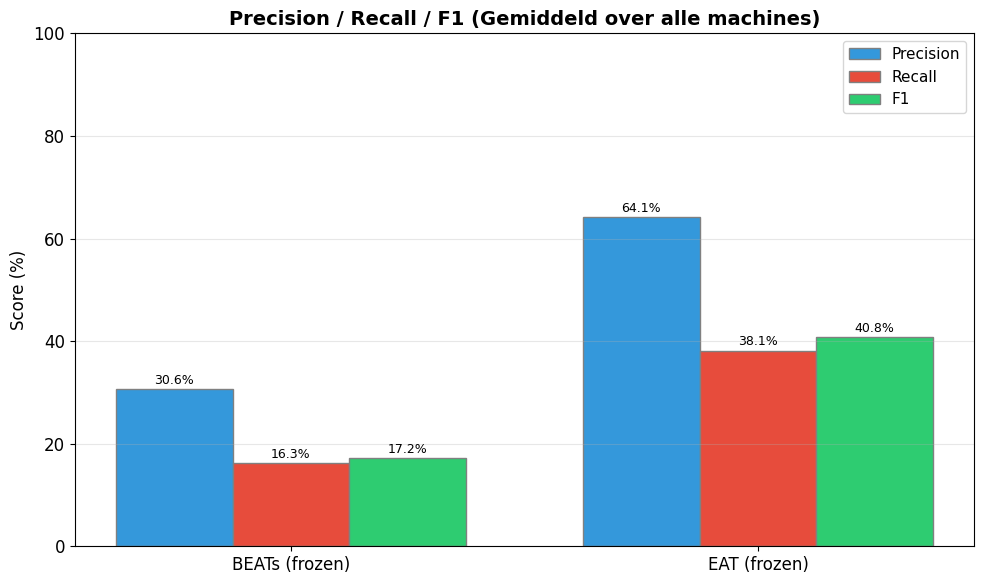

In [8]:
# precision, recall en f1 vergelijken tussen BEATs en EAT (gemiddeld over alle machines)
model_names = ["BEATs (frozen)", "EAT (frozen)"]
metrics_prf = ["Precision", "Recall", "F1"]

# per model het gemiddelde van precision, recall en f1 over alle machines
avg_prf = {}
for model_name in model_names:
    results = raw_results[model_name]
    avg_prf[model_name] = {
        "Precision": np.mean([r["Precision"] for r in results]),
        "Recall": np.mean([r["Recall"] for r in results]),
        "F1": np.mean([r["F1"] for r in results]),
    }

# x-posities en breedte voor de staven, kleuren per metric
x = np.arange(len(model_names))
width = 0.25
colors_prf = ['#3498db', '#e74c3c', '#2ecc71']

fig, ax = plt.subplots(figsize=(10, 6))
# per metric een reeks staven tekenen (naast elkaar)
for i, metric in enumerate(metrics_prf):
    vals = [avg_prf[m][metric] for m in model_names]
    bars = ax.bar(x + (i-1)*width, vals, width, label=metric, color=colors_prf[i], edgecolor='gray')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%',
                ha='center', fontsize=9)

ax.set_ylabel('Score (%)')
ax.set_title('Precision / Recall / F1 (Gemiddeld over alle machines)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Korte analyse en conclusies


### EAT (frozen) doet het goed
EAT (frozen, zonder fine tuning) presteert al goed ten opzichte van de baseline, gemiddeld beter of vergelijkbaar op AUC source, en beter op AUC target en pAUC. Voor valve zijn de scores erg hoog. BEATs scoort over het algemeen slechter dan EAT.

### pAUC
Ook op pAUC (strengere maat) doet EAT het beter dan de baseline, BEATs blijft bij elke machine rond random. pAUC gebruikt dezelfde standaard als DCASE (50% = random, 100% = perfect).

### Mogelijke verklaring voor deze resultaten

EAT werkt waarschijnlijk goed omdat het CLS token een compacte, samenvattende representatie levert van het hele audiofragment (Chen et al., 2024). 

BEATs faalt voor sommige machines mogelijk door mean-pooling die subtiele temporele patronen wegmiddelt (Chen et al., 2022).  De uiteindelijke vector is gewoon het gemiddelde van alle tijdsstappen. Alles wordt over de tijd gemiddeld (Chen et al., 2022). Dat betekent dus dat BEATs het hele geluid samen vat tot één getal over de tijd, waardoor kleine veranderingen (bijv. een korte afwijking) die op een defect kunnen wijzen, wegvallen. Verder zijn beide modellen getraind op AudioSet, niet specifiek op industriegeluiden. 



### References

Chen, W., Liang, Y., Ma, Z., Zheng, Z., & Chen, X. (2024). EAT: Self-supervised pre-training with efficient audio transformer. arXiv preprint arXiv:2401.03497.

Chen, S., Wu, Y., Wang, C., Liu, S., Tompkins, D., Chen, Z., & Wei, F. (2022). Beats: Audio pre-training with acoustic tokenizers. arXiv preprint arXiv:2212.09058.